# **Milestone 2 Model Inference**

========================================================================================================

Milestone 2 Inference

Name  : Bagus Rifky Riyanto

Batch : HCK-27


This program is used to analyze topic "Customers Loan Request Prediction for NIOOS Bank"


========================================================================================================

## Import Libraries

In [1]:
#import libraries
import pickle
import pandas as pd
import seaborn as sns

Explanation:

We will uses Pandas, Pickle, and Seaborn libraries for inference process. Pandas is uses for create and manipulate table, pickle is uses for imorting the model for inference process, and Seaborn for visualisation.

## Load Model

In [2]:
with open('model.pkl', 'rb') as file:
  model_inf = pickle.load(file)

## Process Inference

### Input Data

In [3]:
user = {'person_age': 28.0,
        'person_gender': 'male',
        'person_education': 'Bachelor',
        'person_income': 50000.0,
        'person_emp_exp': 5,
        'person_home_ownership': 'RENT',
        'loan_amount': 8500,
        'loan_intent': 'PERSONAL',
        'loan_int_rate': 8.00,
        'loan_percent_income': 0.16,
        'cred_hist_length': 6.00,
        'credit_score': 500,
        'prev_loan_defaults': 'No'
        }

user_data = pd.DataFrame([user])
user_data

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amount,loan_intent,loan_int_rate,loan_percent_income,cred_hist_length,credit_score,prev_loan_defaults
0,28.0,male,Bachelor,50000.0,5,RENT,8500,PERSONAL,8.0,0.16,6.0,500,No


Input data for the inference process is consists of:
- Age: 28.0
- Gender: male
- Education: Bachelor:
- Annual income: 50000.0
- Employment experience: 5
- Home ownership: RENT
- Requested loan amount: 8500
- Loan intetion: PERSONAL
- Interest rate: 8.00
- Percentage of loan from annual income: 0.16
- History of credit length: 6.00
- Credit score: 500
- Previous loan defaults: No

In [4]:
# filter with only uses column in the model
user_inf = user_data[['person_income', 'loan_int_rate', 'loan_percent_income',
                     'person_home_ownership', 'prev_loan_defaults']]
user_inf

,person_income,loan_int_rate,loan_percent_income,person_home_ownership,prev_loan_defaults
0,50000.0,8.0,0.16,RENT,No


## Model Predictions

In [5]:
# prediction result
y_pred_inf = model_inf.predict(user_inf)
if y_pred_inf[0] == 0:
    print(F'Loan not approved')
elif y_pred_inf[0] == 1:
    print(f"Loan approved")

Loan not approved


In [ ]:
# import fixed dataset
data = pd.read_csv('fix_data.csv')
df = data.copy()
df_lc_app = df[df['loan_status'] == 1]

c:\Users\Asus\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='credit_score', ylabel='Count'>

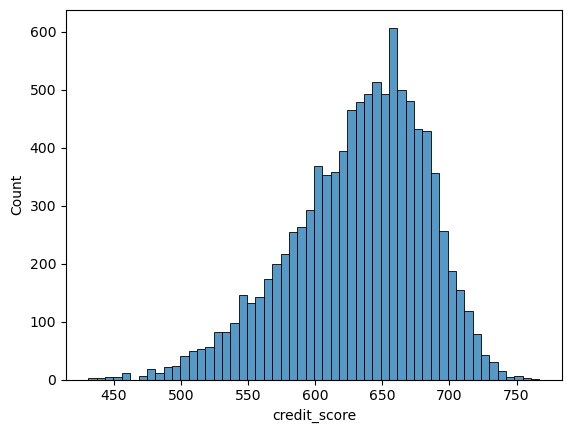

In [ ]:
# visualise the credit score distribution
sns.histplot(df_lc_app, x = 'credit_score')

Explanation:

From the prediction result, loan isn't approved. We need to take a look what influenced model to get this results. Histogram above is a credit score distribution for customers' with approved loan. Our client has 500 credit score. On the histogram, we can see that the number of customers' with 500 credit score is quite low. It is indicate this is one of the factor that contribute to prediction results.